Active Device: cuda
GPU Detected: NVIDIA GeForce RTX 5060 Laptop GPU


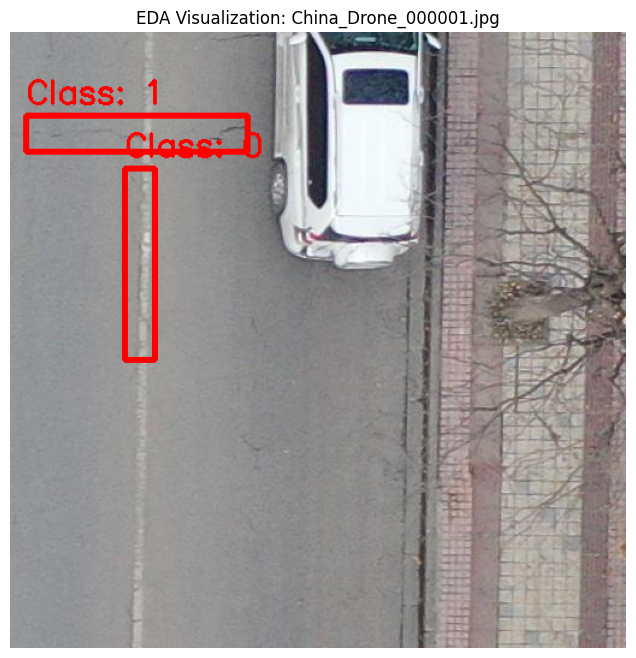

Total training images found: 26869


In [11]:
import os
import cv2
import matplotlib.pyplot as plt
import torch

# 1. Hardware Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")

# 2. Define relative paths (Notebook is in /Model, Dataset is in /Dataset)
base_path = r"../Dataset/RDD_SPLIT"
train_images = os.path.join(base_path, "train", "images")
train_labels = os.path.join(base_path, "train", "labels")

# 3. Visualization Function for YOLO format
def plot_yolo_image(image_name):
    img_path = os.path.join(train_images, image_name)
    label_path = os.path.join(train_labels, image_name.replace('.jpg', '.txt'))
    
    # Read and convert image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        return
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    # Draw bounding boxes if label exists
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                # YOLO format: class_id x_center y_center width height (normalized)
                class_id, x_center, y_center, width, height = map(float, line.strip().split())
                
                # Denormalize to pixel coordinates
                x1 = int((x_center - width / 2) * w)
                y1 = int((y_center - height / 2) * h)
                x2 = int((x_center + width / 2) * w)
                y2 = int((y_center + height / 2) * h)
                
                # Draw Box and Label
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                cv2.putText(img, f"Class: {int(class_id)}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    else:
        print("No label file found for this image (Background image).")

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"EDA Visualization: {image_name}")
    plt.axis('off')
    plt.show()

# 4. Run the visualization on the first available image
sample_images = [f for f in os.listdir(train_images) if f.endswith('.jpg')]
if sample_images:
    plot_yolo_image(sample_images[0])
    print(f"Total training images found: {len(sample_images)}")
else:
    print("No images found. Double-check your relative folder paths.")